In [110]:
import jax.numpy as jnp
from jax.scipy.linalg import solve
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator 
import numpy as np  

# Implicit method (4.2.5) 

In [111]:
# ---- Parameters ----

#method
V_MAX = 201
M = 1000
x_max = 3
x_min = -12

#option
option_type = "put"  # "put" or "call"
T = 1
K = 40

#stocks
r = 0.04
delta = 0.02
sigma = 0.4

In [112]:
# ---- Grid setup ----
x = jnp.linspace(x_min, x_max, V_MAX)
x_interior = x[1:-1]  # length V_MAX - 2

delta_x = (x_max - x_min) / (V_MAX - 1)
tau_max = 0.5 * sigma**2 * T
delta_tau = tau_max / (M - 1)
lamb = delta_tau / (delta_x ** 2)

In [113]:
# ---- Initial condition w(x, 0) ----
q_delta = 2 * (r - delta) / (sigma ** 2)

if option_type == "call":
    initial = jnp.maximum(
        jnp.exp(0.5 * x_interior * (q_delta + 1)) - jnp.exp(0.5 * x_interior * (q_delta - 1)),
        0
    )
else:  # put
    initial = jnp.maximum(
        jnp.exp(0.5 * x_interior * (q_delta - 1)) - jnp.exp(0.5 * x_interior * (q_delta + 1)),
        0
    )

w = jnp.zeros((V_MAX - 2, M))
w = w.at[:, 0].set(initial)


In [114]:
# ---- Construct A matrix - equation (4.18) ----
diag_main = (1 + 2 * lamb) * jnp.ones(V_MAX - 2)
diag_off = -lamb * jnp.ones(V_MAX - 3)
A = jnp.diag(diag_main) + jnp.diag(diag_off, 1) + jnp.diag(diag_off, -1)

In [115]:
# ---- Time stepping - equation (4.19) ----
def step_fn(w_nu):
    return solve(A, w_nu, assume_a='pos') #solve the linear system of equations

for nu in range(M - 1):
    w = w.at[:, nu + 1].set(step_fn(w[:, nu]))

In [116]:
# ---- Undo transformation to pass from w(x,tau) to v(x, tau) - equation (4.3)----
tau = jnp.linspace(0, tau_max, M)
q = 2 * r / sigma**2
factor = jnp.exp(
    -0.5 * (q_delta - 1) * x_interior[:, None] -
    (0.25 * (q_delta - 1)**2 + q) * tau[None, :]
)
v = K * factor * w

In [117]:
# ---- Interpolation and change of variables from v(x, tau) to V(S, t) ----
v_np = np.array(v)
x_np = np.array(x_interior)
tau_np = np.array(tau)
v_interp = RegularGridInterpolator((x_np, tau_np), v_np, bounds_error=False, fill_value=None)

def V(S, t):
    x_val = np.log(S / K)
    tau_val = 0.5 * sigma**2 * (T - t)
    return v_interp([x_val, tau_val])

## Debug

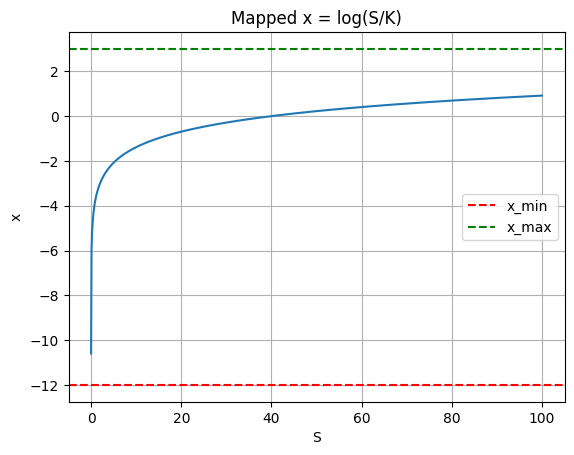

In [118]:
S_vals = np.linspace(1e-3, 100, 1000)
x_vals = np.log(S_vals / K)
plt.plot(S_vals, x_vals)
plt.axhline(x_min, color='r', linestyle='--', label='x_min')
plt.axhline(x_max, color='g', linestyle='--', label='x_max')
plt.legend()
plt.title("Mapped x = log(S/K)")
plt.xlabel("S")
plt.ylabel("x")
plt.grid()
plt.show()


## Visualization

C:\Users\matze\AppData\Local\Temp\ipykernel_24056\2373621669.py:8: RuntimeWarning: divide by zero encountered in log
  x_val = np.log(S / K)


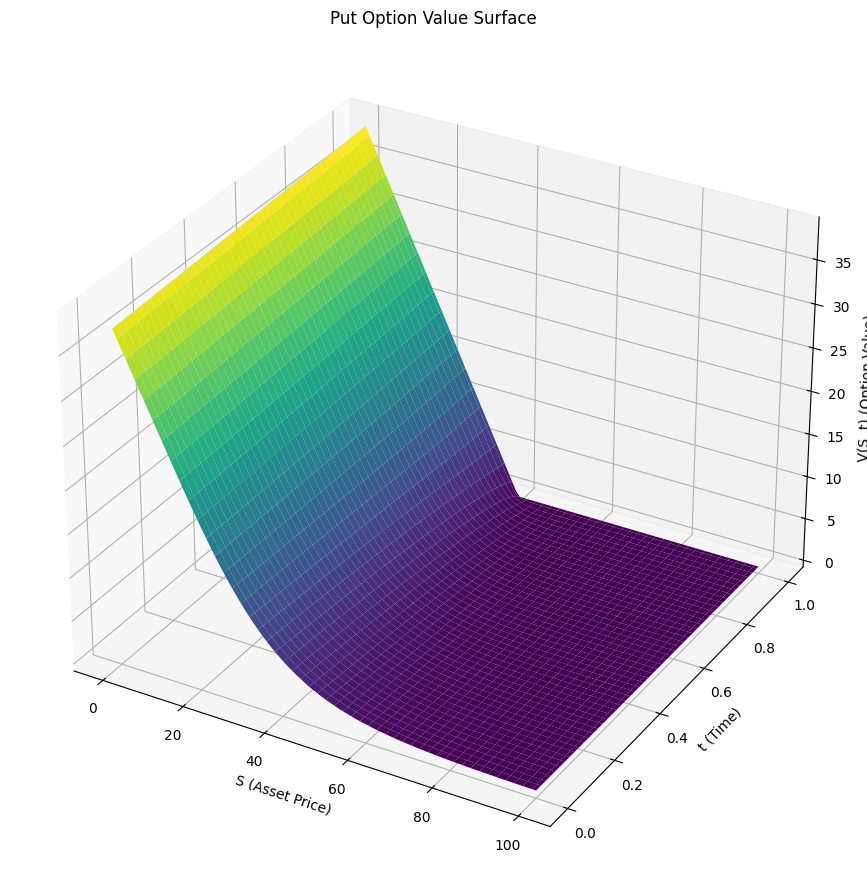

In [119]:
S_vals = np.linspace(0, 100, 100)
t_vals = np.linspace(0, T, 100)
S_grid, t_grid = np.meshgrid(S_vals, t_vals)
V_func = np.vectorize(V)
V_grid = V_func(S_grid, t_grid)

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, t_grid, V_grid, cmap='viridis')
ax.set_xlabel('S (Asset Price)')
ax.set_ylabel('t (Time)')
ax.set_zlabel('V(S, t) (Option Value)')
ax.set_title(f"{option_type.capitalize()} Option Value Surface")
plt.tight_layout()
plt.show()


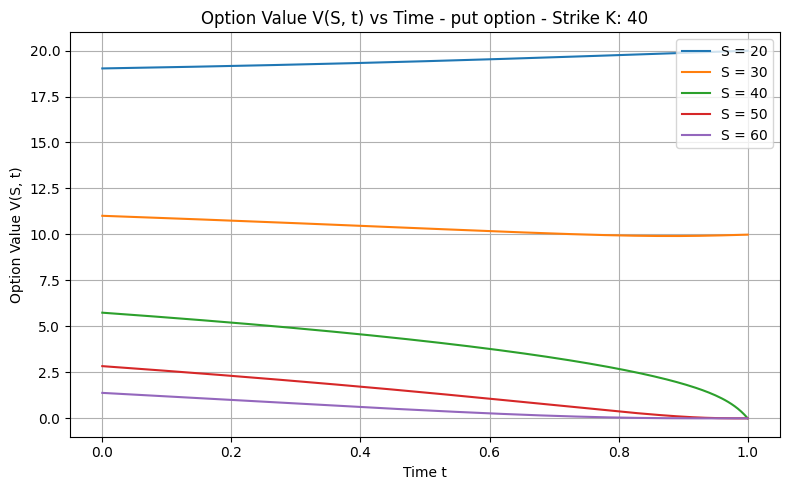

In [123]:
def plot_V_over_time(S_list):
    t_vals = np.linspace(0, T, 200)
    plt.figure(figsize=(8, 5))
    for S in S_list:
        values = [V(S, t) for t in t_vals]
        plt.plot(t_vals, values, label=f"S = {S}")
    plt.title(f"Option Value V(S, t) vs Time - {option_type} option - Strike K: {K}")
    plt.xlabel("Time t")
    plt.ylabel("Option Value V(S, t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_V_over_time([20, 30, 40, 50, 60])


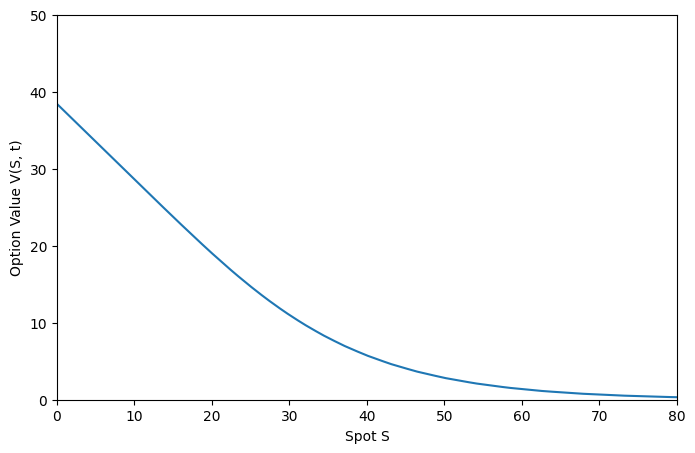

In [130]:
plt.figure(figsize=(8, 5))
t = 0.0
S_vals = np.linspace(0.01, 100, 300)
values = [V(S, t) for S in S_vals]
plt.plot(S_vals, values)
plt.xlabel("Spot S")
plt.ylabel("Option Value V(S, t)")
plt.xlim(0, 80)
plt.ylim(0, 50)
plt. show()

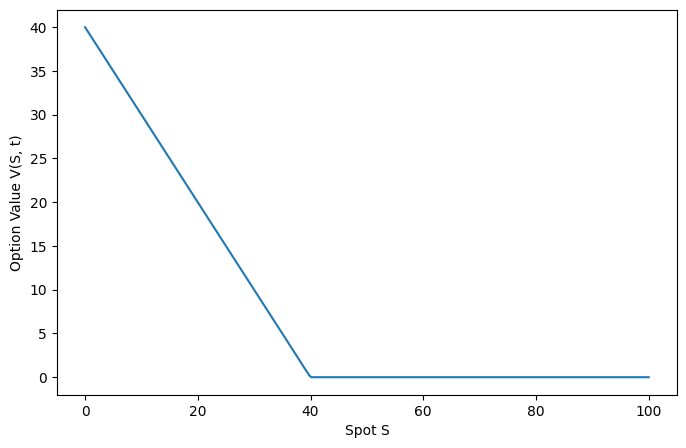

In [131]:
plt.figure(figsize=(8, 5))
t = 1.0
S_vals = np.linspace(0.01, 100, 300)
values = [V(S, t) for S in S_vals]
plt.plot(S_vals, values)
plt.xlabel("Spot S")
plt.ylabel("Option Value V(S, t)")
plt. show()